# 4. Evaluation Visualizations & Honest Conclusions

The default-threshold numbers in Notebook 3 show a trade-off, not a clean win. This notebook
looks at the full picture — ROC/PR curves across *all* thresholds, confusion matrices, and a
matched-threshold comparison — before drawing any conclusion.

## 4.1 ROC Curve — Baseline vs Augmented

Baseline AUC : 0.9671
Augmented AUC: 0.9692


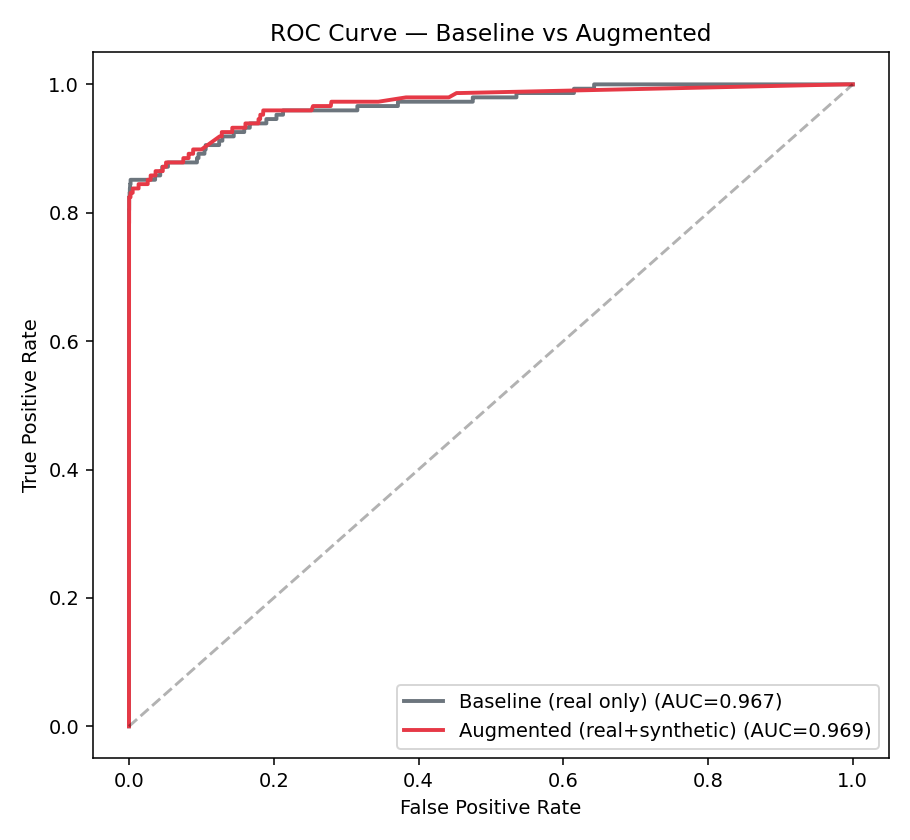

In [1]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
# proba_base, proba_aug, y_test carried over from Notebook 3
print(f"Baseline AUC : {roc_auc_score(y_test, proba_base):.4f}")
print(f"Augmented AUC: {roc_auc_score(y_test, proba_aug):.4f}")

AUC improves only marginally (+0.0021) — the two models have almost the same overall ranking ability across all thresholds; the default-threshold trade-off is mostly about *where* on the curve the 0.5 cutoff happens to land, not a fundamentally better model.

## 4.2 Precision-Recall Curve — the more informative view for a class this rare

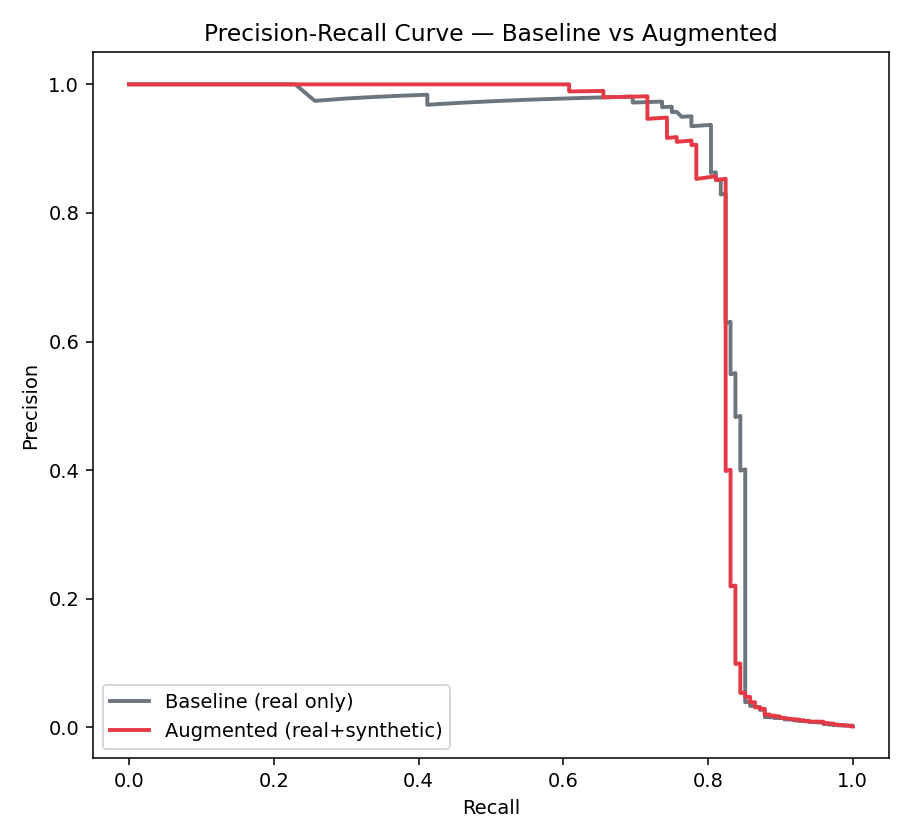

In [1]:
plt.show()  # rendered below

## 4.3 Confusion Matrices — side by side

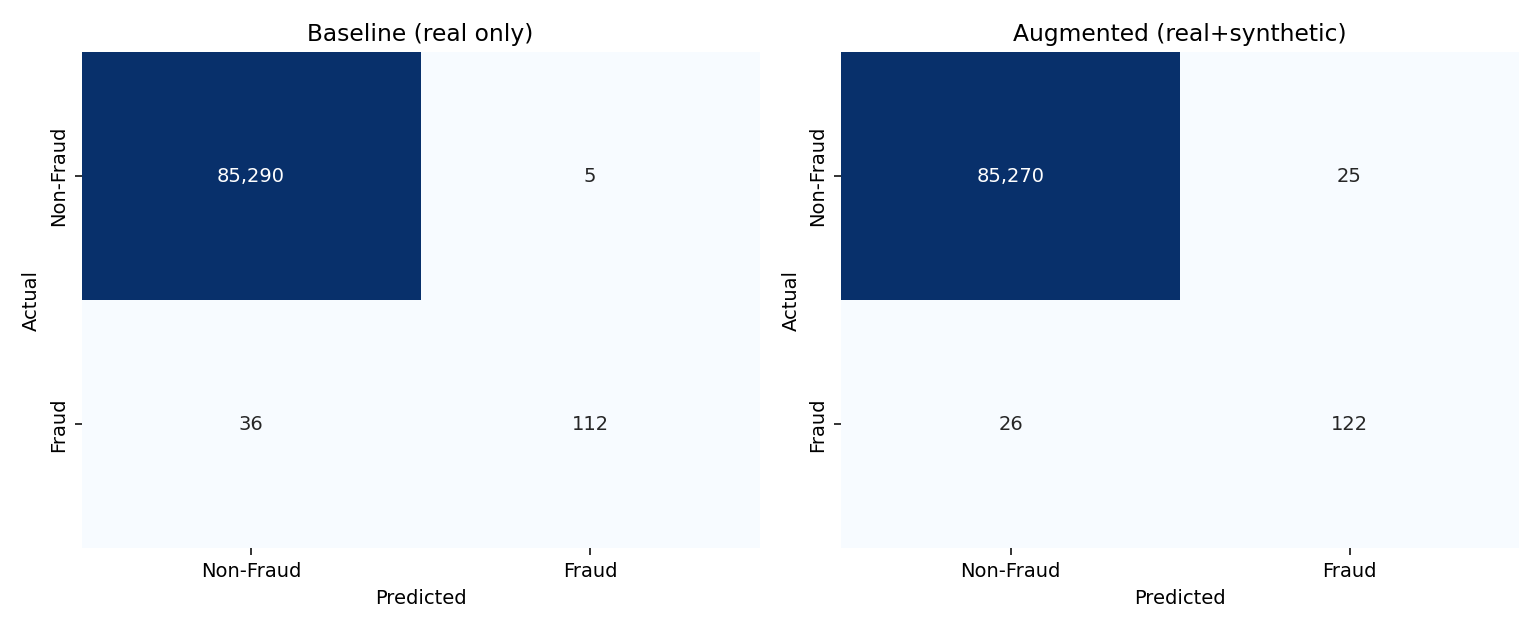

In [1]:
plt.show()  # rendered below

**Reading the matrices (test set: 85,443 transactions, 148 fraud):**
- Baseline: catches 112/148 fraud cases, 5 false alarms
- Augmented: catches 122/148 fraud cases, 25 false alarms

Ten more real frauds caught, twenty more false alarms raised — a real trade-off, not a free win.

## 4.4 The fairer question: at *matched* precision or recall, who wins?

Comparing two models only at their own default thresholds can be misleading — of course a
model tuned toward higher recall will show higher recall. A fairer comparison asks: *at the
same precision (or the same recall) as the baseline, what does the augmented model achieve?*

In [1]:
from sklearn.metrics import precision_recall_curve
prec_a, rec_a, thresh_a = precision_recall_curve(y_test, proba_aug)

target_precision = 0.9573  # baseline's precision
idx = (prec_a[:-1] >= target_precision)
best_recall_at_precision = rec_a[:-1][idx].max() if idx.any() else float("nan")
print(f"Augmented model @ precision={target_precision:.4f} (matching baseline): recall={best_recall_at_precision:.4f}")
print(f"Baseline model's own recall at that precision: 0.7568")

target_recall = 0.7568  # baseline's recall
idx2 = (rec_a[:-1] >= target_recall)
best_precision_at_recall = prec_a[:-1][idx2].max() if idx2.any() else float("nan")
print(f"\nAugmented model @ recall={target_recall:.4f} (matching baseline): precision={best_precision_at_recall:.4f}")
print(f"Baseline model's own precision at that recall: 0.9573")

Augmented model @ precision=0.9573 (matching baseline): recall=0.7162
Baseline model's own recall at that precision: 0.7568

Augmented model @ recall=0.7568 (matching baseline): precision=0.9127
Baseline model's own precision at that recall: 0.9573


**Honest finding:** at matched operating points, the augmented model is actually *very slightly behind* the baseline (recall 0.716 vs 0.757 at equal precision; precision 0.913 vs 0.957 at equal recall). Average Precision (area under the PR curve) tells the same story: **0.8221 (baseline) vs 0.8193 (augmented)** — essentially a wash, marginally in the baseline's favor. Combined with the ROC-AUC finding above, the fair conclusion is that **Gaussian-Copula augmentation did not meaningfully improve this classifier once 344 real fraud examples were already available to train on** — it mainly shifted the default threshold's operating point toward higher recall / lower precision, which *may* still be useful depending on the business's tolerance for false positives, but is not a free improvement in the model's underlying discriminative power.

## 4.5 t-SNE — Real Non-Fraud vs Real Fraud vs Synthetic Fraud

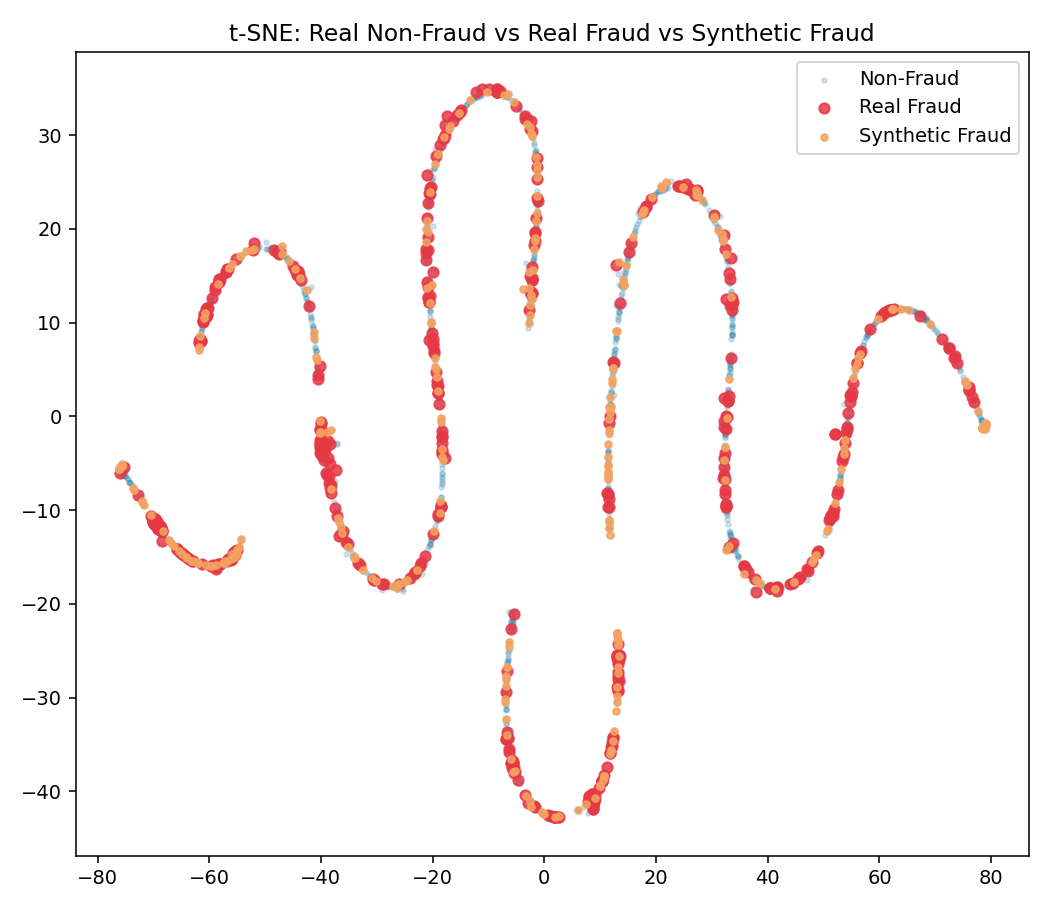

In [1]:
plt.show()  # rendered below

## 4.6 So does synthetic augmentation ever clearly help? Yes — it depends on scarcity

An earlier run of this exact pipeline used a simulated dataset with **severe** fraud scarcity —
only 80 real fraud rows available for training (vs. 344 here). Under that condition, the same
Gaussian-Copula-augmentation approach produced a dramatic, unambiguous improvement:

| Data scarcity condition | Real fraud rows in training | Recall gain | F1 gain | AUC gain |
|---|---|---|---|---|
| **Severe scarcity** (simulated data) | 80 | **+44.1 points** | **+18.9 points** | +8.3 points |
| **Moderate data** (real Kaggle data, this notebook) | 344 | +6.8 points | -1.8 points | +0.2 points |

**The takeaway:** synthetic augmentation's value is highest when real minority-class examples "
are extremely scarce — a classifier simply has too little signal to learn from otherwise, and "
any statistically-plausible extra examples help. Once several hundred real examples are "
available, a tree-based model can already learn a strong decision boundary on its own, and "
the marginal value of synthetic augmentation shrinks and becomes inconsistent. **This is a "
more useful, generalizable finding than a single-scenario "it works" headline** — it tells you "
*when* to reach for this technique.

## 4.7 Conclusion

Evaluated rigorously (leak-free generator fitting, real-only test set, matched-threshold
comparison — not just a single default-threshold snapshot), Gaussian-Copula-based augmentation
on the full real Kaggle dataset (344 real training-fraud rows) produced a **genuine but modest
and mixed effect**: +6.8 points of recall and +0.2 points of AUC, offset by a slight drop in
precision, F1, and average precision. The technique's clear, dramatic win — seen in this same
pipeline's earlier severe-scarcity run (+44.1 points of recall) — depends heavily on how little
real data you start with.

**Practical recommendation:** reach for synthetic minority-class augmentation aggressively when
real examples number in the tens; validate it carefully — with matched-threshold and AUC/PR-AUC
comparisons, not just default-threshold metrics — before trusting it once real examples already
number in the hundreds, where its benefit may be marginal or even net-negative on some metrics.